In [1]:
using Oceananigans
using CairoMakie
using CairoMakie.Colors
using Printf

include("../src-fig/figures/preinitial_conditions.jl")
include("../src-simulation/parameters.jl")
include("../src-simulation/base_state.jl")
include("../src-simulation/grid_faces.jl")

[ Info: Oceananigans will use 4 threads


get_grid_faces (generic function with 1 method)

The preinitial condition of the simulation is a tilted front above a thermocline, with a jet in thermal wind balance
$$
b_0(x, z) = \Delta bf\left (\frac{x}{\ell} + a\frac{z+H/2}{H}\right )g'\left(\frac{z + H}{\lambda H}\right) + b_\infty(z),
\quad
v_0(x, z) = \int_{-\infty}^{z} b_0(x, z)\,\text{d}z \approx  \frac{H\Delta b}{\ell f}\left [f\left (\frac{x}{\ell} + a\frac{z+H/2}{H}\right )-f\left (\frac{x}{\ell} - \frac{a}{2}\right )\right ]
$$
with
$$
f(s) = \frac{1}{2}\big(1 + \tanh(s)\big), \quad g(s) = \ln (1 + e^s), \quad \text{and} \quad b_\infty(z) = -\lambda HN^2_0g\left(-\frac{z + H}{\lambda H}\right)
$$
where $\Delta b$ is the frontal buoyancy change, $\ell$ is the frontal half-width, $H$ is the mixed-layer depth, $N_0$ is the thermocline buoyancy frequency and $\lambda$ is the thermocline transition width. The parameter $a$ controls the tilt of the isopycnals and its purpose will be explained later. At the surface, the velocity and vorticity are approximately
$$
v \approx \frac{H\Delta b}{\ell f}f'\left (\frac{x}{\ell}\right ) \quad \text{and} \quad \zeta \approx \frac{H\Delta b}{\ell^2 f}f''\left (\frac{x}{\ell}\right )
$$

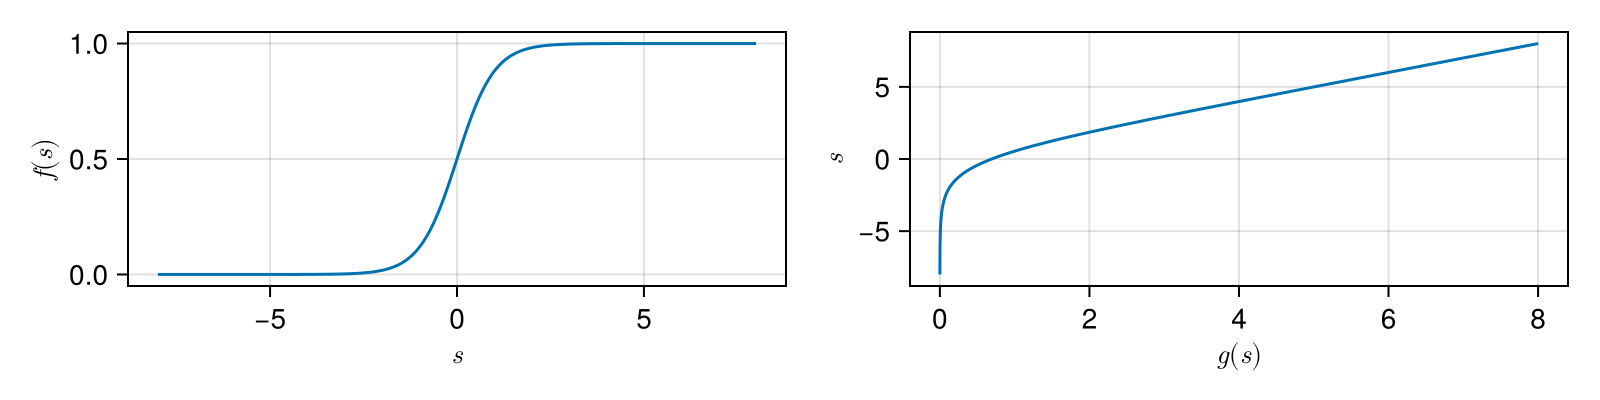

In [2]:
fig = Figure(; size = (800, 200))
s = range(-8, 8, 256)

ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"f(s)"
)
lines!(ax, s, f)

ax = Axis(fig[1, 2];
    xlabel = L"g(s)",
    ylabel = L"s"
)
lines!(ax, g.(s), s)

fig

Simulation input parameters start with defining length, height and time scales via the mixed layer deformation radius $L_D$, mixed layer depth $H = \beta_H L_D$ and the Coriolis frequency $f$. The end-point of 1D frontogenesis has $\text{Ri} = 1$ and the half-width of SG frontogenesis has $\ell = L_D$. Isopycnals are tilted such that $a=1$. We use this front as a reference, which defines a bulk deformation radius of any front 

$$
N^2 = \frac{a\Delta b}{H}f'\left (\frac{x}{\ell} + a\frac{z+H/2}{H}\right ) \quad S = \frac{\Delta b}{\ell f}f'\left (\frac{x}{\ell} + a\frac{z+H/2}{H}\right ) 
$$
$$
\text{Ri} = \frac{aN^2}{S^2} = \frac{\ell^2 f^2}{H\Delta b}\frac{1}{f'\left (\frac{x}{\ell} + \frac{z+H/2}{H}\right )} \implies \text{Ri}_\text{min} = 2a\frac{\ell^2 f^2}{H\Delta b}
$$
$$
L_D^2 = \frac{\Delta b H}{2f^2}
$$
For the front to reach this length scale consistently we need
$$
\Delta b = \frac{2L_Df^2}{\beta_H}
$$
and, if the initial width $\ell = \beta_\ell L_D$
$$
v \approx 2\frac{L_D f}{\beta_\ell} f'\left (\frac{x}{\ell}\right ) \quad \text{and} \quad \zeta \approx \frac{2f}{\beta_\ell^2}f''\left (\frac{x}{\ell}\right )
$$
The thermocline stratification is chosen to have a deformation radius $\beta_0 =8$ times greater than the mixed layer.

In [ ]:
ip = (; f=1, L=1, βℓ=1, βH=1, β₀=8)
sp = create_simulation_parameters(ip)

fig = Figure(; size = (800, 200))
xs = range(-2sp.L, 2sp.L, 256)
zs = range(-sp.H, 0, 256)

bD = [front_buoyancy(x, z, sp) for x in xs, z in zs]
vD = [approximate_front_velocity(x, z, sp) for x in xs, z in zs]

ax = Axis(fig[1, 1];
    xlabel = L"x / L_D",
    ylabel = L"z / H",
    limits = (-2sp.L, 2sp.L, -sp.H, 0)
)


ctf = contourf!(ax, xs, zs, vD; 
    colormap = :balance, 
    levels = range(-1, 1, 10)
)

contour!(ax, xs, zs, bD; 
    levels = -10sp.Δb:(sp.Δb/6):sp.Δb, 
    color = :black
)
Colorbar(fig[1, 2], ctf; label=L"v / L_D f")

fig

Fronts are parametrised relative to this reference state with ratios $\beta_H$ and $\beta_\ell$. We also use $a$ to force $\text{Ri}_\text{min} = 1$, which expedites mixing
$$
\ell = \beta_\ell L_D,  \quad \text{Ri}_\text{min} = a\beta_\ell^2 = 1, \quad v_\text{max} =  \frac{L_D f}{\beta_\ell}, \quad \text{Ro}_\text{max} \approx 0.7698\frac{f}{\beta_\ell^2}
$$
The simulation domain is, also,
$$
L_x = \beta_x L_D, \quad L_h = \beta_h L_D, \quad L_z = 1.5H.
$$
Grid sizes $N_x, N_h, N_y, N_z$ are input, with $L_y = N_y L_h / N_h$. The grid has a variable spacing in the x direction, with a central, high-resolution region and two outer regions with quadratically expanding across-front grid size. For a grid with face indices $[-N_x/2, N_x/2]$, cell faces are at
$$
x_\text{faces}(n) = \frac{L_h}{N_h}n + \frac{L_x - \frac{N_x}{N_h}L_h}{4(N_x - N_h)^3} \times \left \{ \begin{array}{ll}
(n + \frac{N_h}{2})^3 & -\frac{N_x}{2} \leq n \leq -\frac{N_h}{2}\\
0 & -\frac{N_h}{2} \leq n \leq \frac{N_h}{2} \\
(n - \frac{N_h}{2})^3 & \frac{N_h}{2} \leq n \leq \frac{N_x}{2}
\end{array}\right .
$$
Finally, the surface buoyancy flux, specific wind stress magnitude and background strain are expressed simply as 
$$
B = \beta_B L_D^2f^3\quad \tau = \beta_\tau L_D^2 f^2 \quad \alpha = \beta_\alpha f
$$

Fixing the geometry of the simulation, we get a six-dimensional space of physically different simulations:
$$
\beta_H, \beta_B, \beta_\tau, \beta_\alpha, \theta, \beta_0
$$
where $\theta$ is the angle of the wind (we use $\theta=0$ north and $\theta = \pi/2$ east)

# Simulation set
We run dimensional simulations based on typical sizes of the Coriolis frequency and mixed layer deformation radius.
$$
f = 10^{-4}~\text{s}^{-1}\quad L_D = 1~\text{km}
$$

The simulation domain parameters
$$
(N_x, N_y, N_z) = (1024, 128, 64), \quad N_h = 768, \quad \beta_x = 32, \quad \beta_h = 4
$$

A typical strain Rossby number used is $\beta_\alpha = 0.1$.
Cooling of $\beta_B=0.05$ $(100 \,\text{W}\,\text{m}^{-2})$ 

## Initial width
We first run some simulations to determine an appropriate initial width for the front.
$$
\beta_\ell \in \{2, 4, 6, 8\}, \quad \beta_\alpha = 0.1, \quad \beta_B = 0.05, \quad \beta_\tau = 0.0
$$

Based on the results of the above, we choose
$$
\beta_\ell = 6, \quad \beta_x = 20, \quad \beta_h = 3
$$
and
$$
(N_x, N_y, N_z) = (1024, 128, 64), \quad N_h = 768
$$
This gives a central region resolution of
$$
\Delta x = \Delta y = 3.9\,\text{m}\quad \Delta z = 2.34\,\text{m} \implies \Delta x : \Delta z = 1:1.7
$$
We can run many of these simulations. We also intend to run a process study on a parameter set of interest, with
$$
(N_x, N_y, N_z) = (4096, 512, 256), \quad N_h = 3072
$$
and resolution
$$
\Delta x = \Delta y = 0.98\,\text{m}\quad \Delta z = 0.59\,\text{m}
$$

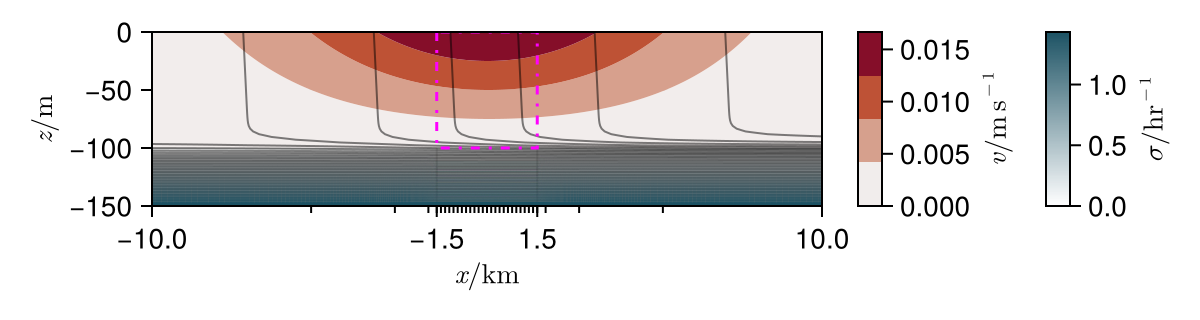

In [24]:
ip = (;
    run_time = 8e5, start_time = -4e5, save_time = 1e3,
    f = 1e-4, L = 1e3,
    βx = 20, βh = 3,
    Nx = 1024, Nh = 768, Ny = 128, Nz = 64,
    βℓ = 6, βH = 0.1,
    βα = 0.1, βB = 0.05, βτ = 0.01, β₀ = 5, θτ = 0.0,
    comment = ""
)

sp = create_simulation_parameters(ip)
preinitial_conditions(sp)

We run the above simulation for varying values of the depth, cooling, strain rate and winds

|Set|$\beta_H$|$\beta_B$|$\beta_\alpha$|$\beta_\tau$|$\theta$|
|---|---|---|---|---|---|
|Depth & cooling|$\{0.06, 0.1, 0.14\}$|$\{0.01, 0.03, 0.05, 0.1, 0.2\}$|$0.1$|$0$| - |
|Strain|$0.1$|$\{0.03, 0.1\}$|$\{0.05, 0.2\}$|$0$| - |
|Wind N|$0.1$|$0.03$|$0.1$|$\{0.01, 0.03, 0.05\}$|$0$|
|Wind E|$0.1$|$0.03$|$0.1$|$\{0.01, 0.03, 0.05\}$|$\pi/2$|

With cooling, pre-initialisation is performed for $60T_\text{mix}$. Simulations are run until $\alpha t = 10$. The simulation state is saved every $1/f$ during pre-initialisation and $0.3/f$ after the strain turns on. Later post-processing for down-front means, slices, and other fields. The same initialised state is used for the different values of the strain.
Filenames are `beta_H-beta_B-beta_alpha-beta_tau-[C, N, E]` where underscores are used instead of `.`.

We also run a couple of grid convergence tests
|Set|$N_x$|$N_h$|$\beta_x$|$\beta_h$|
|---|---|---|---|---|
|Size|1000|700|20|\{2, 3, 4, 5\}|
|Outer|\{800, 900, 1000, 1100\}|700|20|3|

Inner size doesn't seem to have an effect as long as it contains the front. I'm going to use $\beta_h=3$. Arrest seems pretty insensitive to resolution. For the loads of simulations, it seems like $(1400 (1024), 128, 64)$ is good. This takes 2 hours to do $60/f$. Run one initialisation, then two $50/f$ jobs for three hours each, scaled when resolution changes.

In [10]:
ip = (;
    run_time = 8e5, start_time = -4e5, save_time = 1e3,
    f = 1e-4, L = 1e3,
    βx = 20, βh = 3,
    Nx = 1024, Nh = 768, Ny = 128, Nz = 64,
    βℓ = 6, βH = 0.1,
    βα = 0.1, βB = 0.01, βτ = 0.01, β₀ = 5, θτ = 0.0,
    comment = ""
)

for βH in [0.06, 0.1, 0.14], βB in [0.01, 0.03, 0.05, 0.1, 0.2]
    sp = create_simulation_parameters(merge(ip, (; βH, βB)))
    println(βH, " ", βB, " ", @sprintf "%.1f" (60 * sp.T_mix / 1e5))
end

0.06 0.01 4.3
0.06 0.03 3.0
0.06 0.05 2.5
0.06 0.1 2.0
0.06 0.2 1.6
0.1 0.01 6.0
0.1 0.03 4.2
0.1 0.05 3.5
0.1 0.1 2.8
0.1 0.2 2.2
0.14 0.01 7.5
0.14 0.03 5.2
0.14 0.05 4.4
0.14 0.1 3.5
0.14 0.2 2.8
